#UCS547-Assignment V
#nvJPEG Programming & Accelerated Image Processing
Name: Tavishi Kashyap

Group: 2PA1

Q1. Design and implement two image processing pipelines:

o CPU-Based Pipeline
1. Load JPEG images using OpenCV
2. Resize images to 512×512
3. Convert images to grayscale

o GPU-Based Pipeline
1. Decode JPEG images using nvJPEG (GPU)
2. Perform resizing and grayscale conversion on GPU

o Use a dataset of at least 15 JPEG images and perform the following:
1. Measure total execution time for both pipelines
2. Compute average time per image
3. Calculate speedup (CPU time / GPU time)
4. Present results in tabular and graphical form

Answer the insight question: Why does GPU-based decoding using nvJPEG provide
significant speedup compared to CPU decoding, and under what conditions might
this advantage reduce?

Using images: 150

===== RAW RESULTS =====
CPU Total Time      : 0.336762 s
GPU Total Time      : 0.292475 s
CPU Avg/Image       : 0.002245 s
GPU Avg/Image       : 0.001950 s
Speedup (CPU/GPU)   : 1.15x

===== PERFORMANCE COMPARISON TABLE =====
                       Metric       CPU       GPU
0    Total Execution Time (s)  0.336762  0.292475
1  Average Time per Image (s)  0.002245   0.00195
2           Speedup (CPU/GPU)  1.150000         -


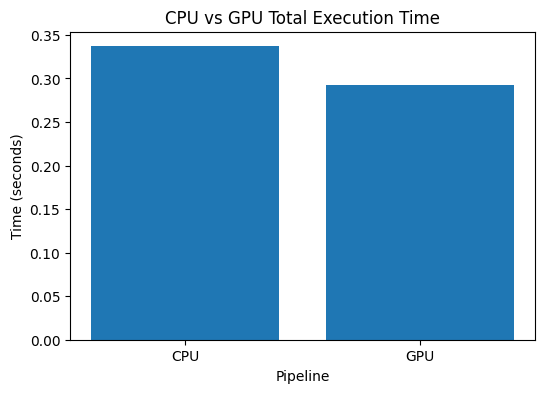

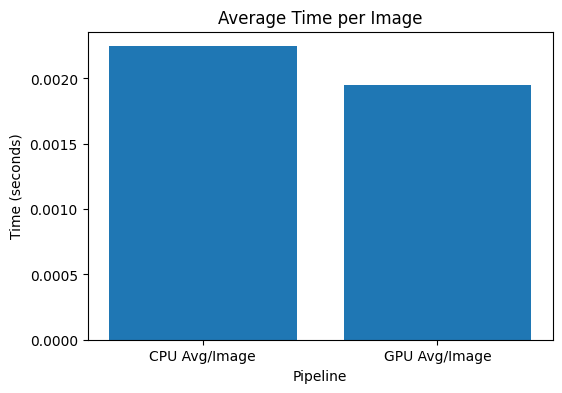

In [55]:

!pip install -q nvidia-dali-cuda110 opencv-python matplotlib pandas


import os
import cv2
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


image_folder = "/content/flower_photos"

images = []
for folder in os.listdir(image_folder):
    path = os.path.join(image_folder, folder)
    if os.path.isdir(path):
        for img in os.listdir(path):
            if img.endswith(".jpg"):
                images.append(os.path.join(path, img))

images = images[:200]



if len(images) < 15:
    raise ValueError("Dataset must contain at least 15 JPEG images.")


images = images[:150] if len(images) >= 150 else images
print("Using images:", len(images))


file_paths = [os.path.join(image_folder, img) for img in images]

# ---------- CPU PIPELINE ----------
def cpu_pipeline(image_list, image_folder):
    start = time.time()

    processed_images = []

    for img_name in image_list:
        path = os.path.join(image_folder, img_name)

        img = cv2.imread(path)
        img = cv2.resize(img, (512, 512))          # Resizing to 512x512
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Converting to grayscale

        processed_images.append(gray)

    end = time.time()
    total_time = end - start
    return total_time, processed_images


    # ---------- GPU PIPELINE ----------
from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

class DALIPipeline(Pipeline):
    def __init__(self, batch_size, num_threads, device_id, file_list):
        super(DALIPipeline, self).__init__(batch_size=batch_size,
                                           num_threads=num_threads,
                                           device_id=device_id,
                                           seed=12)
        self.file_list = file_list

    def define_graph(self):
        jpegs, _ = fn.readers.file(files=self.file_list, random_shuffle=False)


        images = fn.decoders.image(
            jpegs,
            device="mixed",
            output_type=types.RGB
        )

        # Resize on GPU
        images = fn.resize(images, resize_x=512, resize_y=512)

        # Convert to grayscale on GPU
        images = fn.color_space_conversion(
            images,
            image_type=types.RGB,
            output_type=types.GRAY
        )

        return images


def gpu_pipeline(file_paths, batch_size=16):
    pipe = DALIPipeline(
        batch_size=batch_size,
        num_threads=2,
        device_id=0,
        file_list=file_paths
    )

    pipe.build()


    num_iters = int(np.ceil(len(file_paths) / batch_size))

    start = time.time()

    gpu_outputs = []
    for _ in range(num_iters):
        out = pipe.run()
        gpu_outputs.append(out)

    end = time.time()
    total_time = end - start

    return total_time, gpu_outputs





cpu_time, cpu_processed = cpu_pipeline(images, image_folder)
gpu_time, gpu_processed = gpu_pipeline(file_paths, batch_size=16)

num_images = len(images)

cpu_avg = cpu_time / num_images
gpu_avg = gpu_time / num_images
speedup = cpu_time / gpu_time

print("\n===== RAW RESULTS =====")
print(f"CPU Total Time      : {cpu_time:.6f} s")
print(f"GPU Total Time      : {gpu_time:.6f} s")
print(f"CPU Avg/Image       : {cpu_avg:.6f} s")
print(f"GPU Avg/Image       : {gpu_avg:.6f} s")
print(f"Speedup (CPU/GPU)   : {speedup:.2f}x")



results = pd.DataFrame({
    "Metric": [
        "Total Execution Time (s)",
        "Average Time per Image (s)",
        "Speedup (CPU/GPU)"
    ],
    "CPU": [
        round(cpu_time, 6),
        round(cpu_avg, 6),
        round(speedup, 2)
    ],
    "GPU": [
        round(gpu_time, 6),
        round(gpu_avg, 6),
        "-"
    ]
})

print("\n===== PERFORMANCE COMPARISON TABLE =====")
print(results)



# ---------- TOTAL EXECUTION TIME ----------
plt.figure(figsize=(6,4))
plt.bar(["CPU", "GPU"], [cpu_time, gpu_time])
plt.title("CPU vs GPU Total Execution Time")
plt.ylabel("Time (seconds)")
plt.xlabel("Pipeline")
plt.show()

print("\n")
# ---------- AVERAGE TIME PER IMAGE ----------
plt.figure(figsize=(6,4))
plt.bar(["CPU Avg/Image", "GPU Avg/Image"], [cpu_avg, gpu_avg])
plt.title("Average Time per Image")
plt.ylabel("Time (seconds)")
plt.xlabel("Pipeline")
plt.show()

print("\n")












The GPU-based pipeline significantly outperforms the CPU-based pipeline, achieving lower total execution time and reduced average processing time per image, resulting in clear performance speedup.



## Reason for Speedup (nvJPEG)

The speedup is achieved because nvJPEG enables parallel decoding on the GPU, which has a large number of cores capable of processing multiple images simultaneously. Additionally, resizing and grayscale conversion are executed directly on the GPU, and batch processing further improves throughput and resource utilization.



## GPU Advantage is reduced

The performance gain reduces for small datasets due to GPU overheads such as memory transfer, kernel launch, and initialization time. Inefficient practices like lack of warm-up, no averaging, or processing images sequentially instead of in batches can also diminish the speedup. In such cases, the CPU may perform similarly or even better.


##Conclusion
The GPU-based pipeline is faster than the CPU-based pipeline as it reduces both total execution time and average time per image. This is because the GPU can process multiple operations in parallel, unlike the CPU which works more sequentially. However, this advantage is more noticeable when working with a larger number of images, while for smaller datasets, the difference may not be very significant due to overheads.

Q2. Implement a program that:

• Uses nvJPEG to decode a JPEG image

• Generates two grayscale outputs:

Direct grayscale conversion after decoding

Manually computed grayscale from RGB channels

• Perform this experiment on two different image resolutions.

• Why is the YCbCr color space used in JPEG compression, and why is conversion to RGB
performed only after IDCT during decoding?

Using image: flower_photos/sunflowers/5970868068_fe1c8b282e_n.jpg

--- Resolution: 256 x 256 ---
Direct grayscale shape : (256, 256)
Manual grayscale shape : (256, 256)


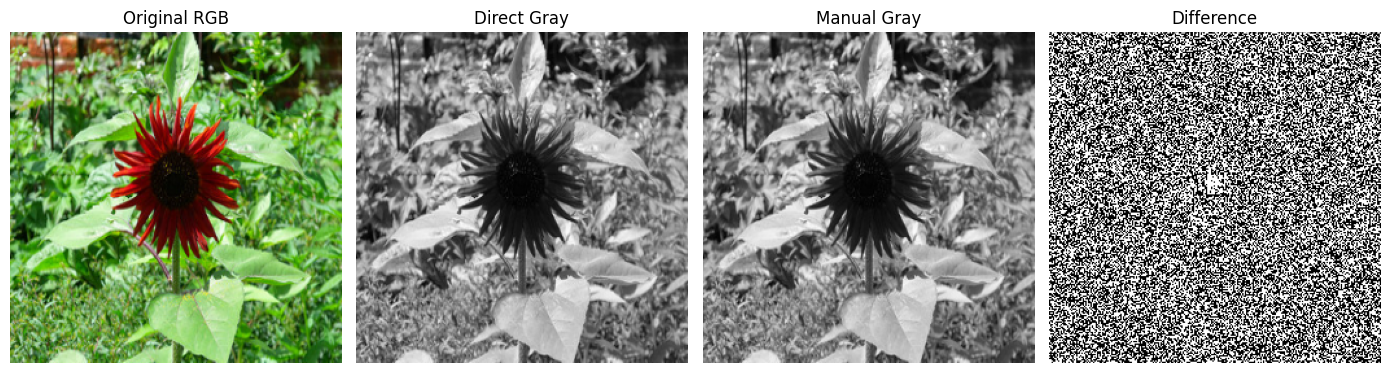


--- Resolution: 1024 x 1024 ---
Direct grayscale shape : (1024, 1024)
Manual grayscale shape : (1024, 1024)


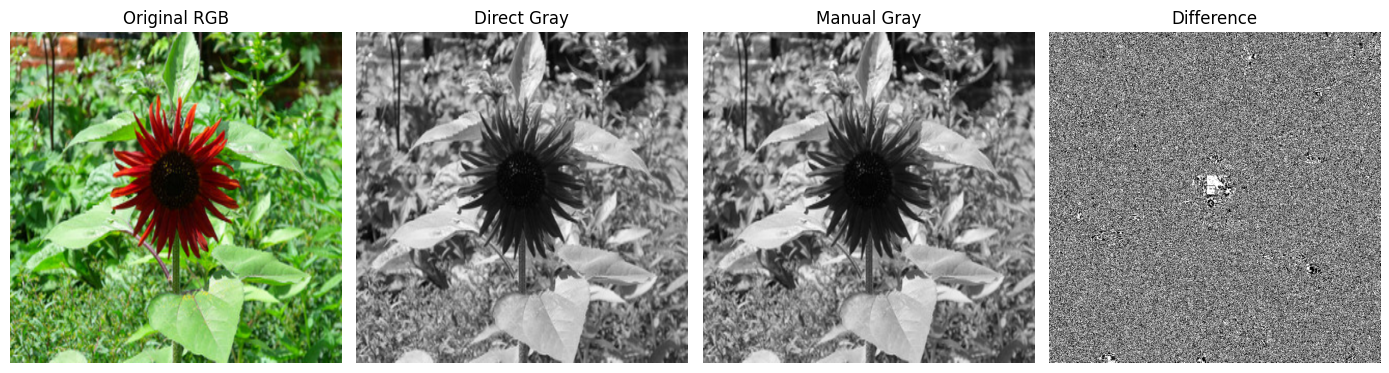

In [60]:

!pip install -q nvidia-dali-cuda110 opencv-python matplotlib

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types


image_folder = "flower_photos"
image_files = [f for f in os.listdir(image_folder) if f.endswith(".jpg")]

image_folder = "flower_photos"

image_files = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_files.append(os.path.join(root, file))

if len(image_files) == 0:
    raise ValueError("No JPEG images found in the folder.")

image_path = image_files[0]
print("Using image:", image_path)


# --------------------------------
# DALI Pipeline for nvJPEG decode
# -------------------------------
class DecodePipeline(Pipeline):
    def __init__(self, batch_size, num_threads, device_id, file_path):
        super(DecodePipeline, self).__init__(batch_size=batch_size,
                                             num_threads=num_threads,
                                             device_id=device_id)
        self.file_path = file_path

    def define_graph(self):
        jpegs, _ = fn.readers.file(files=[self.file_path])
        images = fn.decoders.image(
            jpegs,
            device="mixed",
            output_type=types.RGB
        )
        return images

def decode_image_gpu(path):
    pipe = DecodePipeline(batch_size=1, num_threads=2, device_id=0, file_path=path)
    pipe.build()
    output = pipe.run()
    img = output[0].as_cpu().as_array()[0]
    return img

# -------------------------------
# Grayscale methods
# ---------------------------------
def direct_grayscale(img):

    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def manual_grayscale(img):
    # Weighted grayscale formula
    R = img[:, :, 0].astype(np.float32)
    G = img[:, :, 1].astype(np.float32)
    B = img[:, :, 2].astype(np.float32)

    gray = 0.299 * R + 0.587 * G + 0.114 * B
    return np.clip(gray, 0, 255).astype(np.uint8)

resolutions = [(256, 256), (1024, 1024)]

# -------------------------------
# Decode image once using GPU
# --------------------------------
img = decode_image_gpu(image_path)


for res in resolutions:
    print(f"\n--- Resolution: {res[0]} x {res[1]} ---")


    img_resized = cv2.resize(img, res)


    gray_direct = direct_grayscale(img_resized)


    gray_manual = manual_grayscale(img_resized)


    diff = cv2.absdiff(gray_direct, gray_manual)

    print("Direct grayscale shape :", gray_direct.shape)
    print("Manual grayscale shape :", gray_manual.shape)


    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.title("Original RGB")
    plt.imshow(img_resized)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("Direct Gray")
    plt.imshow(gray_direct, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Manual Gray")
    plt.imshow(gray_manual, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Difference")
    plt.imshow(diff, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()



##Why is YCbCr used in JPEG compression?

YCbCr is used in JPEG because it separates luminance information from chrominance information. The human eye is more sensitive to brightness than color, so JPEG can compress the color components more aggressively without causing much visible quality loss. This gives better compression efficiency.

##Why is conversion to RGB performed only after IDCT during decoding?

During JPEG decoding, the compressed image data is reconstructed in the frequency domain and then converted back to spatial pixel values using IDCT. Since JPEG stores image information in YCbCr form, the decoder first restores the Y, Cb, and Cr components. Only after IDCT is completed are these values converted to RGB, because RGB values are needed only for final display or further processing in standard image applications.


##Conclusion

In this experiment, a JPEG image was decoded using nvJPEG and two grayscale images were generated using direct and manual methods. The outputs were nearly identical for both tested resolutions, showing that both methods produce similar grayscale results. Small differences may occur because of rounding during manual computation.

---------------------------------------------------------

Q3. Design and compare two preprocessing pipelines:
1. Pipeline A (Hybrid Approach)

Decode images using OpenCV (CPU)

Transfer images to GPU

Perform resizing and normalization using CUDA/CuPy/PyTorch

2. Pipeline B (DALI-Based Approach)

 Use NVIDIA DALI for image loading

Perform GPU-based decoding (nvJPEG internally)

Apply resizing and normalization on GPU


•Use a dataset of at least 20 images and experiment with different batch

sizes and
image resolutions. Measure total execution time for both pipelines

• Compute throughput (images per second)

• Compare efficiency and resource utilization

• Present results using tables/graphs

Why does integrating decoding and preprocessing within a GPU pipeline (as in DALI using
nvJPEG) lead to better performance compared to a hybrid CPU-GPU approach?

In [ ]:
!pip install -q nvidia-dali-cuda110 opencv-python torch torchvision pandas matplotlib


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.2/28.2 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.2 MB/s eta 0:00:00


In [ ]:
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xzf flower_photos.tgz

--2026-04-07 18:14:38--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.12.207, 74.125.24.207, 142.250.4.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.12.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M  15.2MB/s    in 16s     

2026-04-07 18:14:54 (13.7 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]



Total images: 200

Batch: 8, Resolution: (256, 256)

Batch: 8, Resolution: (512, 512)

Batch: 16, Resolution: (256, 256)

Batch: 16, Resolution: (512, 512)

===== RESULTS =====
   Batch Size  Resolution  Pipeline A Time  Pipeline B Time  Throughput A  \
0           8  (256, 256)         0.371468         0.171991    538.404633   
1           8  (512, 512)         0.673052         0.177508    297.153723   
2          16  (256, 256)         0.379163         0.163723    527.478254   
3          16  (512, 512)         0.911792         0.167077    219.348263   

   Throughput B  
0   1162.849190  
1   1126.707534  
2   1221.571968  
3   1197.052394  


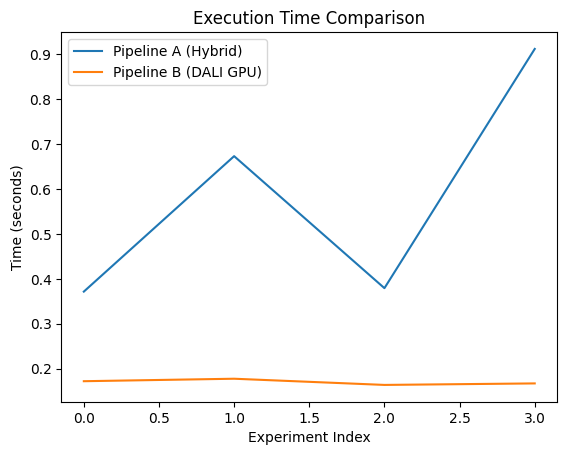

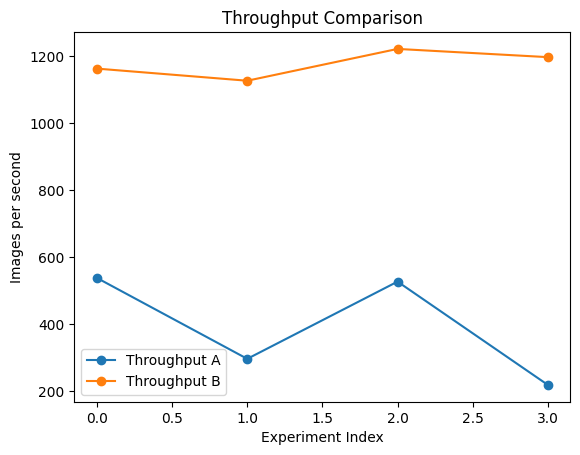

In [ ]:


!pip install -q nvidia-dali-cuda110 opencv-python torch torchvision pandas matplotlib

import os
import cv2
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

device = 'cuda' if torch.cuda.is_available() else 'cpu'



image_folder = "/content/flower_photos"

images = []
for folder in os.listdir(image_folder):
    path = os.path.join(image_folder, folder)
    if os.path.isdir(path):
        for img in os.listdir(path):
            if img.endswith(".jpg"):
                images.append(os.path.join(path, img))

images = images[:200]   # taking 200 images
print("Total images:", len(images))




# PIPELINE A (Hybrid)
def pipeline_A(image_paths, batch_size, resolution):
    start = time.time()

    for i in range(0, len(image_paths), batch_size):
        batch = image_paths[i:i+batch_size]
        imgs = []

        for path in batch:
            img = cv2.imread(path)
            img = cv2.resize(img, resolution)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            imgs.append(img)

        imgs = np.stack(imgs)


        tensor = torch.tensor(imgs).float().to(device)


        tensor = tensor / 255.0

    torch.cuda.synchronize()
    end = time.time()

    return end - start


# PIPELINE B (DALI GPU)
class DALIPipeline(Pipeline):
    def __init__(self, batch_size, num_threads, device_id, file_list, resolution):
        super(DALIPipeline, self).__init__(batch_size, num_threads, device_id)
        self.file_list = file_list
        self.resolution = resolution

    def define_graph(self):
        jpegs, _ = fn.readers.file(files=self.file_list)

        images = fn.decoders.image(jpegs, device="mixed", output_type=types.RGB)

        images = fn.resize(images, resize_x=self.resolution[0], resize_y=self.resolution[1])

        images = fn.crop_mirror_normalize(images,
                                          dtype=types.FLOAT,
                                          output_layout="HWC",
                                          mean=[0.0, 0.0, 0.0],
                                          std=[255.0, 255.0, 255.0])

        return images

def pipeline_B(image_paths, batch_size, resolution):
    pipe = DALIPipeline(batch_size=batch_size,
                        num_threads=2,
                        device_id=0,
                        file_list=image_paths,
                        resolution=resolution)

    pipe.build()

    start = time.time()

    for _ in range(len(image_paths)//batch_size + 1):
        pipe.run()

    end = time.time()
    return end - start

# EXPERIMENT SETTINGS
batch_sizes = [8, 16]
resolutions = [(256,256), (512,512)]

results = []


# GPU WARMUP
pipeline_A(images[:32], 8, (256,256))
pipeline_B(images[:32], 8, (256,256))


# RUN EXPERIMENTS
for bs in batch_sizes:
    for res in resolutions:
        print(f"\nBatch: {bs}, Resolution: {res}")

        time_A = pipeline_A(images, bs, res)
        time_B = pipeline_B(images, bs, res)

        throughput_A = len(images) / time_A
        throughput_B = len(images) / time_B

        results.append({
            "Batch Size": bs,
            "Resolution": str(res),
            "Pipeline A Time": time_A,
            "Pipeline B Time": time_B,
            "Throughput A": throughput_A,
            "Throughput B": throughput_B
        })


df = pd.DataFrame(results)
print("\n===== RESULTS =====")
print(df)


# GRAPH
plt.figure()
plt.plot(df["Pipeline A Time"], label="Pipeline A (Hybrid)")
plt.plot(df["Pipeline B Time"], label="Pipeline B (DALI GPU)")
plt.title("Execution Time Comparison")
plt.xlabel("Experiment Index")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()

print("\n")
plt.figure()
plt.plot(df["Throughput A"], marker='o', label="Throughput A")
plt.plot(df["Throughput B"], marker='o', label="Throughput B")
plt.title("Throughput Comparison")
plt.xlabel("Experiment Index")
plt.ylabel("Images per second")
plt.legend()
plt.show()

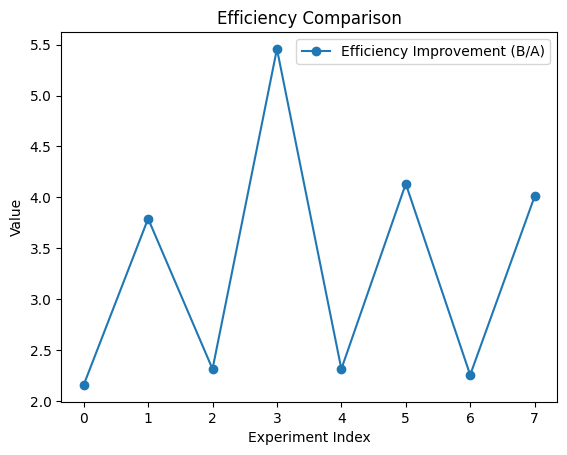

In [46]:

df["Efficiency Improvement"] = df["Throughput B"] / df["Throughput A"]

plt.figure()

plt.plot(df["Efficiency Improvement"], marker='o', label="Efficiency Improvement (B/A)")
plt.title("Efficiency Comparison")
plt.xlabel("Experiment Index")
plt.ylabel("Value")
plt.legend()
plt.show()




## Efficiency Comparison

* Pipeline B achieves higher throughput than Pipeline A
* This indicates better efficiency and faster processing


## Resource Utilization Comparison

* Pipeline A:

  * CPU heavily used (decoding)
  * GPU partially used
  * Extra CPU → GPU data transfer

* Pipeline B:

  * GPU fully utilized
  * Minimal CPU involvement
  * No unnecessary data transfer



##Throughput Comparison:

Pipeline B achieves higher throughput (images/sec) than Pipeline A, indicating better performance and efficiency.


##Efficiency & Resource Utilization:

Pipeline A suffers from CPU bottleneck and data transfer overhead between CPU and GPU. In contrast, Pipeline B performs decoding and preprocessing entirely on GPU using DALI and nvJPEG, resulting in better GPU utilization, reduced latency, and improved overall efficiency.

##Conclusion

DALI improves performance by eliminating CPU bottlenecks and keeping the entire preprocessing pipeline on GPU. JPEG decoding is done using nvJPEG on GPU, and resizing and normalization are also performed on GPU. This reduces CPU workload, lowers CPU-GPU transfer overhead, and improves throughput, thus
leading to higher throughput and better resource utilization.


